In [24]:
import numpy as np 
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

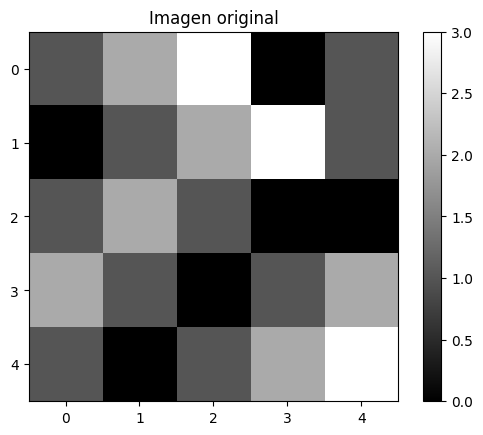

In [25]:
#Matriz simple 
imagen = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 2, 1, 0, 0],
    [2, 1, 0, 1, 2],
    [1, 0, 1, 2, 3]
])

plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.colorbar()
plt.show

In [26]:
#Definir el kernel
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print("Kernel: \n", kernel)

Kernel: 
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


In [27]:
#función de convolución
def convolucion(imagen, kernel, stride=1, padding=0):
    
    if padding > 0:
        imagen = np.pad(imagen, pad_width=padding, mode='constant', constant_values=0)
    
    k_h, k_w = kernel.shape
    i_h, i_w = imagen.shape
    
    # Tamaño de salida
    out_h = (i_h - k_h) // stride + 1
    out_w = (i_w - k_w) // stride + 1
    
    salida = np.zeros((out_h, out_w))
    
    # Convolución
    for i in range(0, out_h):
        for j in range(0, out_w):
            region = imagen[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            salida[i, j] = np.sum(region * kernel)
    
    return salida

Salida sin padding, stride=1:
 [[-4.  2.  4.]
 [ 0.  0.  0.]
 [ 2.  0. -3.]]


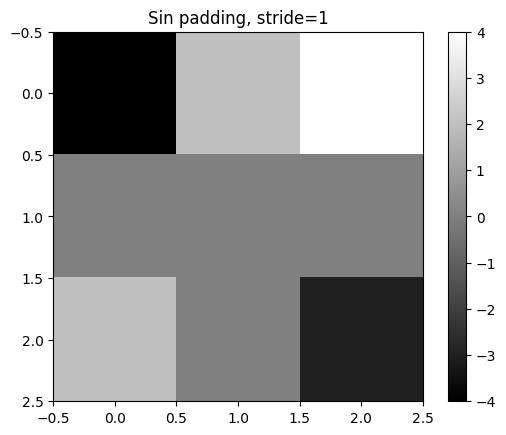

In [28]:
#convolución sin padding y stride
out1 = convolucion(imagen, kernel, stride=1, padding=0)

print("Salida sin padding, stride=1:\n", out1)

plt.imshow(out1, cmap="gray")
plt.title("Sin padding, stride=1")
plt.colorbar()
plt.show()

Salida con padding=1: 
 [[-3. -4.  0.  3.  3.]
 [-5. -4.  2.  4.  3.]
 [-4.  0.  0.  0.  4.]
 [-3.  2.  0. -3.  3.]
 [-1.  2. -2. -4.  3.]]


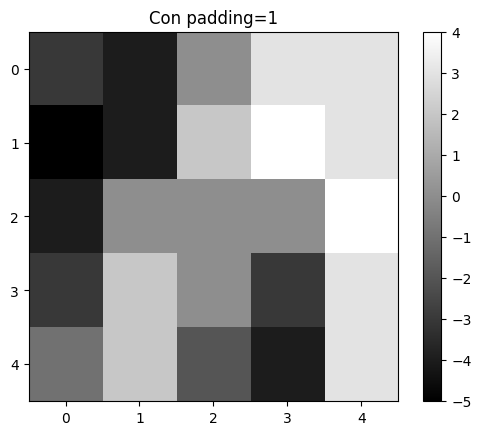

In [29]:
#convolución con padding
out2 = convolucion(imagen, kernel, stride=1, padding=1)

print("Salida con padding=1: \n", out2)

plt.imshow(out2, cmap="gray")
plt.title("Con padding=1")
plt.colorbar()
plt.show()

Salida con stride=2: 
 [[-4.  4.]
 [ 2. -3.]]


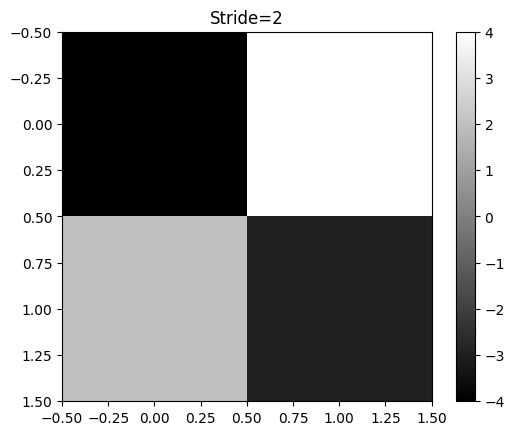

Shape Original:  (5, 5)
Sin padding:  (3, 3)
Con padding:  (5, 5)
Stride:  (2, 2)


In [30]:
#Con stride mayor
out3 = convolucion(imagen, kernel, stride=2, padding=0)

print("Salida con stride=2: \n", out3)

plt.imshow(out3, cmap="gray")
plt.title("Stride=2")
plt.colorbar()
plt.show()

print("Shape Original: ", imagen.shape)
print("Sin padding: ", out1.shape)
print("Con padding: ", out2.shape)
print("Stride: ", out3.shape)

## Análisis y Conclusiones

### CONVOLUCIÓN

La convolución es una operación matemática donde un filtro recorre una matriz para extrar caracteristicas, entre estas caracteristicas tenemos que

- Cada posicón multiplica valores y luego los suma.
- El resultado es un mapa de caracteristicas.

### PADDING

La función del padding es agregar ceros al rededor de una imgen esto con el fin de.

- Mantener el tamaño de la salida
- Evitar perder información en los bordes de las imagenes

### STRIDE

El stride es el que controla cuando se mueve el kernel o el filtro

- **Stride 1**, hace un análisis detallado
- **Stride 2**, hace un análisis mucho más rapido pero menos preciso

en conclusión, con un mayor stride es menor el tamaño de la salida

| Caso | Resultado |
|---|---|
| **Sin Padding** | Muestra una imagen mucho mas pequeña. |
| **Con Padding** | Se conserva el tamaño de la imagen. |
| **Stride = 2  ** | Menos información en las imagenes. |

### Conclusión principal

En conclusión 

- La convolución nos permite extrer caracteristicas importantes de una imagen.
- El padding ayuda a conserver información en los bordes
- El stride reduce la resolución de los resultados
- Stride pequeño obtienes mas detalle
- Stride grande obtienes mas eficiencia